In [14]:
import os
# Change to the directory where the script is located to be able to import local modules
os.chdir("..")

In [17]:
from pathlib import Path
cwd = Path.cwd()
print(cwd)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM


# Libraries 

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Check the Index Dataframe 

In [19]:
df = pd.read_parquet(cwd/"data"/"index"/"runs.parquet")
df.head()

,dgp,run_id,path,created_at,git_commit,params,split_file,n,T,p,seed,split_seed
0,blackwell_yamauchi,25b398d6,data\raw\blackwell_yamauchi\25b398d6,2025-09-20T21:14:22Z,4c1c0be,"{'T': 20, 'a': 1.0, 'beta': [-0.5, -0.5], 'gam...",data\splits\blackwell_yamauchi\N500_T20_p2_spl...,500,20,2,1,42


In [7]:
from utils.runs import load_by_params
dgp = "blackwell_yamauchi"
n = 500
T = 20
seed = 1 
a = 1.0
p = 2 

beta_dict = {2:  [-0.5, -0.5], 4: [-0.5, -0.5, 1.0, -0.5]}
gamma_dict = {2: [1.0, 0.5], 4: [1.0, 0.5, 1.0, 1.0]}

params = {
    "phi": 0.3,
    "tau_F": 1.0, 
    "tau_C": 0.3,
    "mean_x": -0.5, 
    "offdiag": 0.2,
    "sigma_eps": 1.0, 
    "max_lag_x": 0, 
    "max_lag_d": 3,
    "split_seed": 42
    }


treatment_model = "logit"

params["treatment_model"] = treatment_model

cfg = {"n": n, "T": T, "seed": seed, "a": a, "p": p,
       "beta": beta_dict[p], "gamma": gamma_dict[p], **params}
df, manifest = load_by_params(".", dgp, cfg)

In [12]:
df.head()

,patient_id,t,D,Y,x0,x1,lag1_D,lag2_D,lag3_D
0,0,1,1,NaN,-0.394058,-0.873730,0.0,0.0,0.0
1,0,2,0,NaN,0.416246,-2.285390,1.0,0.0,0.0
2,0,3,1,NaN,-0.697784,-0.662207,0.0,1.0,0.0
3,0,4,1,NaN,-0.814508,1.937430,1.0,0.0,1.0
4,0,5,1,NaN,1.256169,-0.106798,1.0,1.0,0.0


In [13]:
manifest

{'dgp': 'blackwell_yamauchi',
 'run_id': '25b398d6',
 'created_at': '2025-09-20T21:14:22Z',
 'path': 'data\\raw\\blackwell_yamauchi\\25b398d6',
 'git_commit': '4c1c0be',
 'python': '3.12.3',
 'node': 'Ali-Setareh',
 'params': {'n': 500,
  'T': 20,
  'seed': 1,
  'a': 1.0,
  'p': 2,
  'beta': [-0.5, -0.5],
  'gamma': [1.0, 0.5],
  'phi': 0.3,
  'tau_F': 1.0,
  'tau_C': 0.3,
  'mean_x': -0.5,
  'offdiag': 0.2,
  'sigma_eps': 1.0,
  'max_lag_x': 0,
  'max_lag_d': 3,
  'split_seed': 42,
  'treatment_model': 'logit'},
 'script': 'experiments/run_simulation.py',
 'split_file': 'data\\splits\\blackwell_yamauchi\\N500_T20_p2_splitseed42.json',
 'split_info': {'by': 'unit', 'split_seed': 42}}

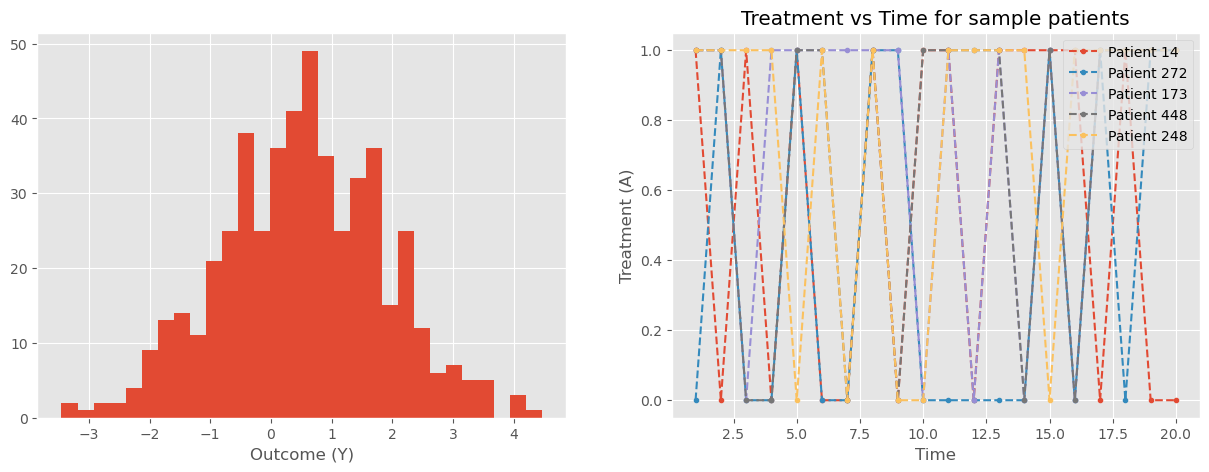

In [10]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

num = 5
seed = 42
sample_ids = df["patient_id"].drop_duplicates().sample(num)
#sample_ids = [train_ids[1881]]
fig,ax = plt.subplots(1,2,figsize = (15,5))
for pid in sample_ids:
    sub = df[df.patient_id == pid]
    #ax[0].plot(sub["t"], sub["Y"], "--.",label = f"Patient {pid}")
    ax[1].plot(sub["t"], sub["D"], "--.",label = f"Patient {pid}")

#ax[0].set_xlabel("Time")
#ax[0].set_ylabel("Outcome (Y)")
#ax[0].set_title("Outcome vs Time for sample patients")
#ax[0].legend()

ax[0].hist(df.Y,bins=30)
ax[0].set_xlabel("Outcome (Y)")
#ax[0].set_title("Outcome vs Time for sample patients")
#ax[0].legend()

ax[1].set_xlabel("Time")
ax[1].set_ylabel("Treatment (A)")
ax[1].set_title("Treatment vs Time for sample patients")
ax[1].legend(loc = "upper right")
plt.show()

In [17]:
import plotly.express as px

fig = px.histogram(
    df, 
    x="D", 
    animation_frame="t",   # animate over time
    nbins=20, 
    title="Distribution of D over time", 
    histnorm="probability",
    width=800,   # width in pixels
    height=600   # height in pixels
)
fig.update_layout(yaxis=dict(autorange=True))
fig.show()
